In [28]:
list_integers = [7,5,3,6,9,0,1]

l_max = l_min = list_integers[0]

for i in range(1,len(list_integers)):
    if(list_integers[i] > l_max):
        l_max = lbist_integers[i]
    if(list_integers[i] < l_min):
        l_min = list_integers[i]

print('Max is ',l_max)
print('Min is ',l_min)



Max is  9
Min is  0


In [ ]:
word=input("Enter a string")
word=word.replace(" ","")
word=word.lower()
word1=word[::-1]
if(word==word1):
    print(word," is a palindrome")
else:
    print(word," is not a palindrome")


In [ ]:
def diff(lst,x):
    seen=[]
    for num in lst:
        if (num+x) in seen:
            return(num,num+x)
        if (num-x) in seen:
            return(num,num-x)
        seen.append(num)
lst=[67,45,32,100,33,42,50]
x=67
print("Pair with difference ",x," is ",diff(lst,x))

In [1]:
import pandas as pd
import numpy as np

data = {
'Ticker': ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'WIPRO'],
'Price': [2850.5, 3900.0, 1500.75, 1650.0, 420.3],
'Volume': [1200000, 850000, 1100000, 950000, 700000],
'Sector': ['Energy', 'IT', 'IT', 'Finance', 'IT']
}

df = pd.DataFrame(data = data)

print(df.shape)
print(df.head(3))

print(df.loc[df['Sector'] == 'IT'])

df['Market_Cap_Proxy'] = df['Price'] * df['Volume']
df.sort_values('Market_Cap_Proxy', ascending=False) 
df

(5, 4)
     Ticker    Price   Volume  Sector
0  RELIANCE  2850.50  1200000  Energy
1       TCS  3900.00   850000      IT
2      INFY  1500.75  1100000      IT
  Ticker    Price   Volume Sector
1    TCS  3900.00   850000     IT
2   INFY  1500.75  1100000     IT
4  WIPRO   420.30   700000     IT


,Ticker,Price,Volume,Sector,Market_Cap_Proxy
0,RELIANCE,2850.50,1200000,Energy,3.420600e+09
1,TCS,3900.00,850000,IT,3.315000e+09
2,INFY,1500.75,1100000,IT,1.650825e+09
3,HDFCBANK,1650.00,950000,Finance,1.567500e+09
4,WIPRO,420.30,700000,IT,2.942100e+08


In [2]:
print(df['Price'].mean())
print(df[df['Sector'] == 'IT']['Volume'].sum())

m = df['Market_Cap_Proxy'].max()
print(df.loc[df['Market_Cap_Proxy'] == m, 'Ticker'])

2064.31
2650000
0    RELIANCE
Name: Ticker, dtype: object


In [3]:
scores = np.array([45, 82, 76, 55, 90, 38, 67, 71])
print(np.mean(scores))
print(np.median(scores))
print(np.std(scores))

data_min = np.min(scores)
data_max = np.max(scores)

normalized_data = (scores - data_min) / (data_max - data_min)

print(normalized_data)

indices = np.where(scores > np.mean(scores))[0]
print(indices)


65.5
69.0
16.963195453687373
[0.13461538 0.84615385 0.73076923 0.32692308 1.         0.
 0.55769231 0.63461538]
[1 2 4 6 7]


In [ ]:
import matplotlib.pyplot as plt

daily_return = np.random.normal(loc=0.0008, scale=0.015, size=252)
final_return = np.ones(253)
final_return[0] = 100
for i in range(1, 253):
    final_return[i] = (1 + daily_return[i - 1]) * final_return[i - 1]
final_price = final_return[-1]
max_price = np.max(final_return)

rolling_peak  = np.maximum.accumulate(final_return)
drawdowns     = (final_return - rolling_peak) / rolling_peak * 100
max_drawdown  = drawdowns.min()

print(final_price, max_price, max_drawdown)


plt.figure(figsize=(10, 6))
plt.plot(final_return, label="Asset Price", color="blue", linewidth=1.5)

# Formatting the plot
plt.title(
    "Price vs Day Graph",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Trading Days", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()

# Show the plot
plt.show()


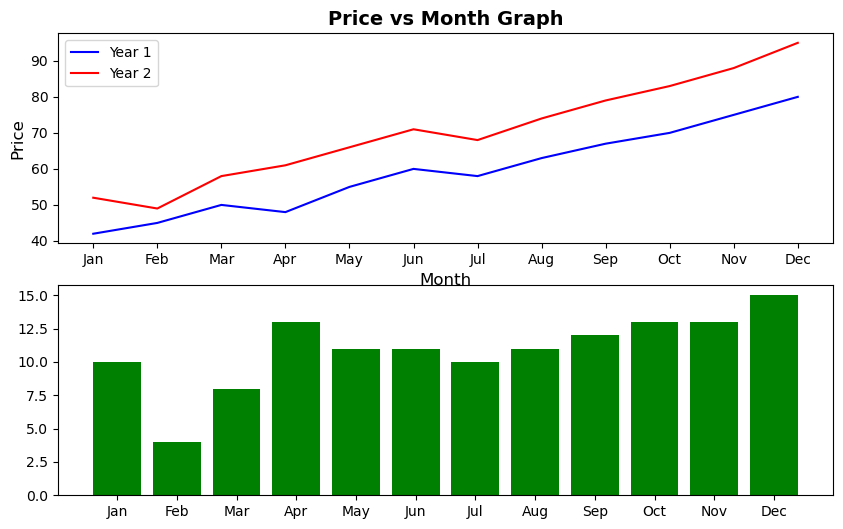

In [14]:
import matplotlib.pyplot as plt

months = ['Jan','Feb','Mar','Apr','May','Jun',
'Jul','Aug','Sep','Oct','Nov','Dec']
year1 = [42, 45, 50, 48, 55, 60, 58, 63, 67, 70, 75, 80]
year2 = [52, 49, 58, 61, 66, 71, 68, 74, 79, 83, 88, 95]

y1_arr = np.array(year1)
y2_arr = np.array(year2)
difference = y2_arr - y1_arr

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)

plt.plot(months, year1, label="Year 1", color="blue", linewidth=1.5)
plt.plot(months, year2, label="Year 2", color="red", linewidth=1.5)
plt.title(
    "Price vs Month Graph",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()

bar_colors = []

for i in range(12):
    if(difference[i] < 0):
        bar_colors.append('red')
    else:
        bar_colors.append('green')


plt.subplot(2, 1, 2)
plt.bar(months, difference,color = bar_colors)


plt.show()



In [20]:
import numpy as np, pandas as pd
df = pd.DataFrame({
'Day': range(1, 11),
'Price': [100, 103, np.nan, 108, 107, np.nan, 112, 115, np.nan, 120],
'Volume': [500, 520, 510, np.nan, 530, 545, np.nan, 560, 570, 580]
})
empty_price = df['Price'].isnull().sum()
empty_volume = df['Volume'].isnull().sum()
print('Empty values in Price: ',empty_price)
print('Empty values in Volume: ',empty_volume)

df['Price'] = df['Price'].ffill()
df['Volume'] = df['Volume'].fillna(df['Volume'].mean())

return_arr = []

for i in range(len(df)):
    if(i == 0):
        return_arr.append(0)
    else:
        prev_val = df.loc[i-1,'Price']
        curr_val = df.loc[i,'Price']

        return_arr.append(((curr_val - prev_val)/prev_val)* 100 )

df['Return'] = return_arr
df


Empty values in Price:  3
Empty values in Volume:  2


,Day,Price,Volume,Return
0,1,100.0,500.000,0.000000
1,2,103.0,520.000,3.000000
2,3,103.0,510.000,0.000000
3,4,108.0,539.375,4.854369
4,5,107.0,530.000,-0.925926
5,6,107.0,545.000,0.000000
6,7,112.0,539.375,4.672897
7,8,115.0,560.000,2.678571
8,9,115.0,570.000,0.000000
9,10,120.0,580.000,4.347826


          Asset_A   Asset_B   Asset_C
Asset_A  1.000000  0.087809  0.064399
Asset_B  0.087809  1.000000  0.198940
Asset_C  0.064399  0.198940  1.000000


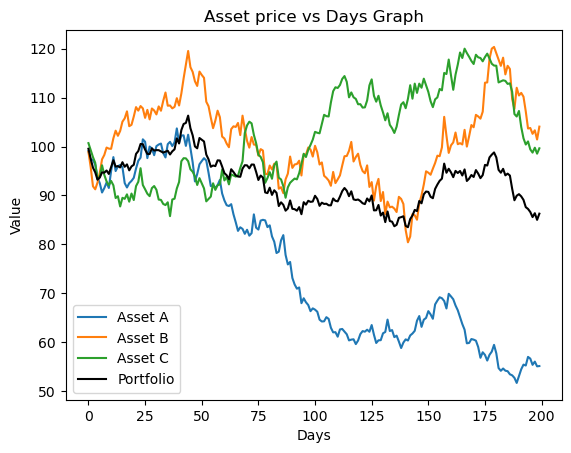

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
returns = np.random.multivariate_normal(
mean=[0.0005, 0.0008, 0.0003],
cov=[[0.0004, 0.0001, 0.00005],
[0.0001, 0.0006, 0.00008],
[0.00005, 0.00008, 0.0003]],
size=200
)
prices = 100 * np.cumprod(1 + returns, axis=0)

df_prices = pd.DataFrame(prices, columns=['Asset_A', 'Asset_B', 'Asset_C'])

df_returns = pd.DataFrame(returns, columns=['Asset_A', 'Asset_B', 'Asset_C'])
corr_matrix = df_returns.corr()
print(corr_matrix)

df_prices['Portfolio'] = 1/3*(df_prices['Asset_A'] + df_prices['Asset_B'] + df_prices['Asset_C'])

plt.plot(df_prices['Asset_A'], label='Asset A')
plt.plot(df_prices['Asset_B'], label='Asset B')
plt.plot(df_prices['Asset_C'], label='Asset C')
plt.plot(df_prices['Portfolio'], label='Portfolio', color='black')

plt.title('Asset price vs Days Graph')
plt.xlabel('Days')
plt.ylabel('Value')
plt.legend()
plt.show()